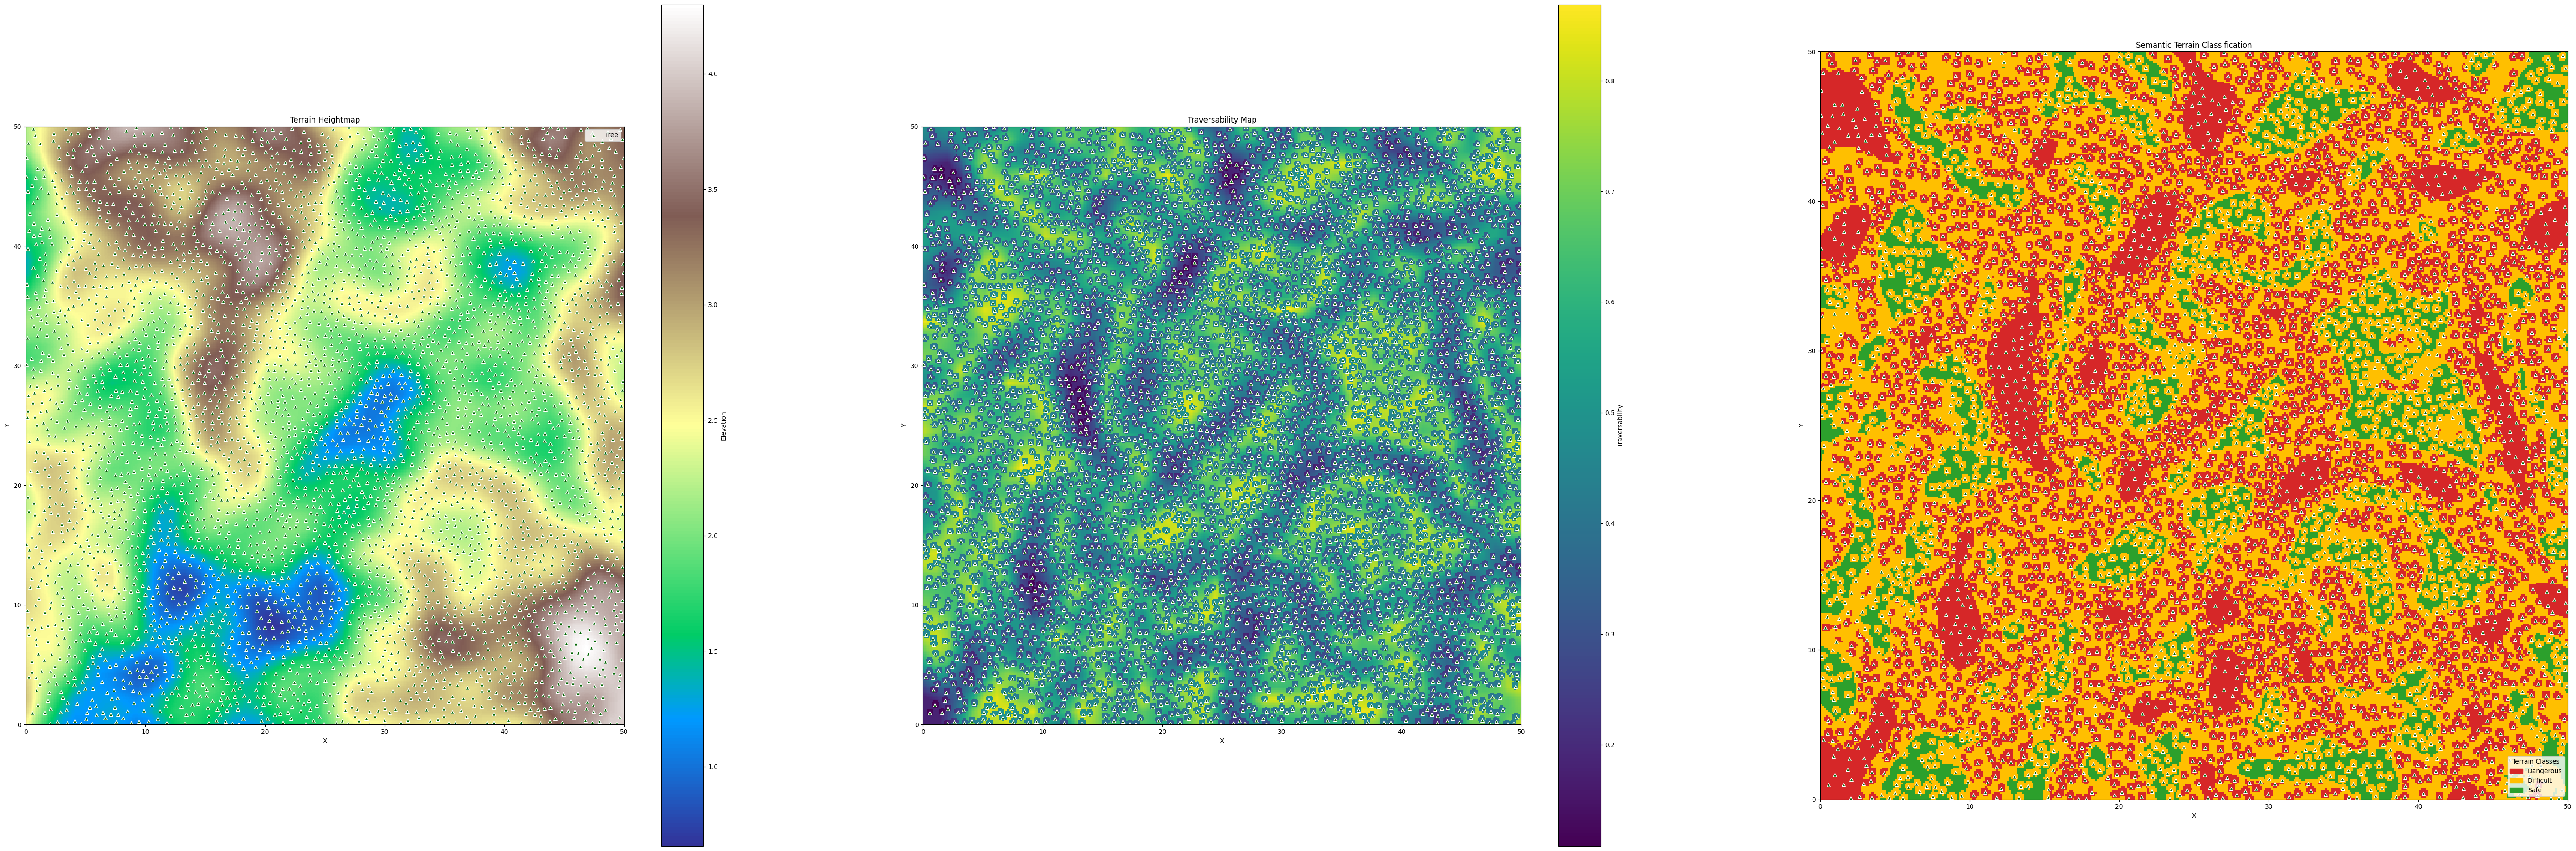

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from forest_gen.heightmap import NOISE_FUNC, heightmap_to_mesh
from forest_gen.travelsibilitymap import generate_traversability_map

from forest_gen.asset_dist import Simulation, Species, Plant

size = 50      #   50x50 metrów.
step = 1       #  1 metr.
mesh = heightmap_to_mesh(NOISE_FUNC, int(size))


RADIUS = 0.5
random_tree = Species("A tree", 5, 0.01, radius=RADIUS)
another_tree = Species("Another tree", 5, 0.02, radius=RADIUS)
bush = Species("Bush", 5, 0.01, radius=RADIUS)

sim = Simulation((size, size), {"tree": {random_tree, another_tree}, "bush": {bush}})
state = [
    Plant((np.random.uniform(10, size-10), np.random.uniform(10, size-10)), random_tree, 0),
    Plant((np.random.uniform(10, size-10), np.random.uniform(10, size-10)), another_tree, 0)
]
state = sim.run_state(10, state)

# radii później
trees = [{"x": tree.coords[0], "y": tree.coords[1]} for tree in state]

trav_map, heightmap = generate_traversability_map(
    mesh=mesh,
    size=size,
    step=step,
    trees=trees,
    max_slope_deg=25,
    slope_weight=0.7,
    tree_penalty=0.4,
    tree_influence_radius=0.3,
    min_altitude=0.0,# calc
    max_altitude=0.0, # calc
    altitude_penalty=0.4,
    altitude_weight=0.3,
    resolution_factor=8,
)

# Klasyfikacja
def classify_terrain(trav_map: np.ndarray) -> np.ndarray:
    classified = np.zeros_like(trav_map, dtype=np.uint8)
    classified[trav_map >= 0.7] = 2   # Safe
    classified[(trav_map >= 0.4) & (trav_map < 0.7)] = 1  # Difficult
    classified[trav_map < 0.4] = 0    # Dangerous
    return classified


class_map = classify_terrain(trav_map)

# Kolormapa
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
terrain_colors = ListedColormap([
    "#d62728",  # 0 = Dangerous (Red)
    "#ffbf00",  # 1 = Difficult (Yellow)
    "#2ca02c",  # 2 = Safe (Green)
])

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(72, 24))
extent = [0, size * step, 0, size * step]

hm = ax1.imshow(heightmap, cmap="terrain", origin="lower", extent=extent)
ax1.set_title("Terrain Heightmap")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
fig.colorbar(hm, ax=ax1, label="Elevation")

tm = ax2.imshow(trav_map, cmap="viridis", origin="lower", extent=extent)
ax2.set_title("Traversability Map")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
fig.colorbar(tm, ax=ax2, label="Traversability")

cm = ax3.imshow(class_map, cmap=terrain_colors, origin="lower", vmin=0, vmax=2, extent=extent)
ax3.set_title("Semantic Terrain Classification")
ax3.set_xlabel("X")
ax3.set_ylabel("Y")

tree_x = [tree["x"] for tree in trees]
tree_y = [tree["y"] for tree in trees]

ax1.scatter(tree_x, tree_y, c="darkgreen", edgecolors="white", s=30, marker="^", label="Tree")
ax2.scatter(tree_x, tree_y, c="darkgreen", edgecolors="white", s=30, marker="^", label="Tree")
ax3.scatter(tree_x, tree_y, c="darkgreen", edgecolors="white", s=30, marker="^", label="Tree")

ax1.legend(loc="upper right")

legend_patches = [
    mpatches.Patch(color="#d62728", label="Dangerous"),
    mpatches.Patch(color="#ffbf00", label="Difficult"),
    mpatches.Patch(color="#2ca02c", label="Safe")
]

ax3.legend(handles=legend_patches, loc="lower right", title="Terrain Classes")

plt.show()


In [32]:
len(trees)


7870